# Expression Matrix QC

This notebook performs basic QC of the processed ImmVar expression matrices prior to variance-partition analysis. QC is performed after removing 265 probes containing non-positive values and applying a log2 transformation.


## Load and Inspect Expression Matrices

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd

combined_expression = pd.read_csv(
    "../data/processed/immvar_expression_log2.csv",
    index_col=0,
)

combined_metadata = pd.read_csv(
    "../data/processed/immvar_metadata.csv",
)

In [2]:
metadata_by_sample = combined_metadata.set_index(
    "geo_accession"
)

cd4_samples = metadata_by_sample.index[
    metadata_by_sample["cell_type"] == "CD4"
]

cd14_samples = metadata_by_sample.index[
    metadata_by_sample["cell_type"] == "CD14"
]

cd4_expr = combined_expression.loc[
    :,
    cd4_samples,
]

cd14_expr = combined_expression.loc[
    :,
    cd14_samples,
]

print("Log2 CD4:", cd4_expr.shape)
print("Log2 CD14:", cd14_expr.shape)

Log2 CD4: (21462, 499)
Log2 CD14: (21462, 485)


## Missing Values and Duplicate Probe IDs

In [3]:
print(cd4_expr.isna().sum().sum())
print(cd14_expr.isna().sum().sum())

0
0


In [4]:
print(cd4_expr.index.duplicated().sum())
print(cd14_expr.index.duplicated().sum())

0
0


## Compare Expression Matrices with Metadata

In [5]:
cd4_meta = pd.read_csv("../data/processed/cd4_metadata.csv")
cd14_meta = pd.read_csv("../data/processed/cd14_metadata.csv")


In [6]:
# Same number of samples?
print(cd4_expr.shape[1], len(cd4_meta))

# Same sample IDs?
print(set(cd4_expr.columns) == set(cd4_meta["geo_accession"]))

# Same order?
print((cd4_expr.columns == cd4_meta["geo_accession"]).all())

499 499
True
True


## Expression Value Distributions

In [7]:
cd4_expr.stack().describe()

count    1.070954e+07
mean     6.921900e+00
std      1.758736e+00
min     -2.162945e+00
25%      5.691420e+00
50%      6.874511e+00
75%      8.041545e+00
max      1.451703e+01
dtype: float64

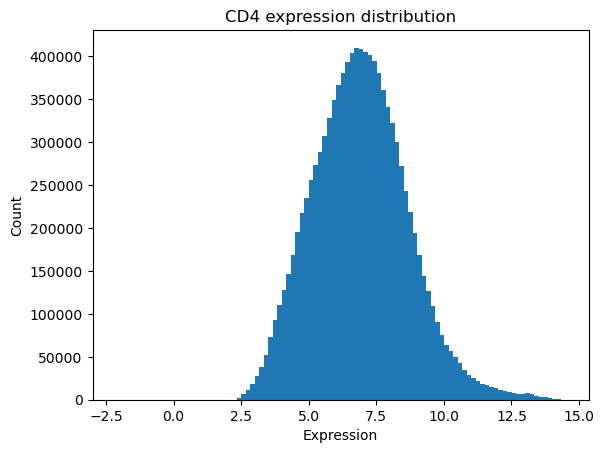

In [8]:

plt.hist(cd4_expr.stack(), bins=100)
plt.title("CD4 expression distribution")
plt.xlabel("Expression")
plt.ylabel("Count")
plt.show()

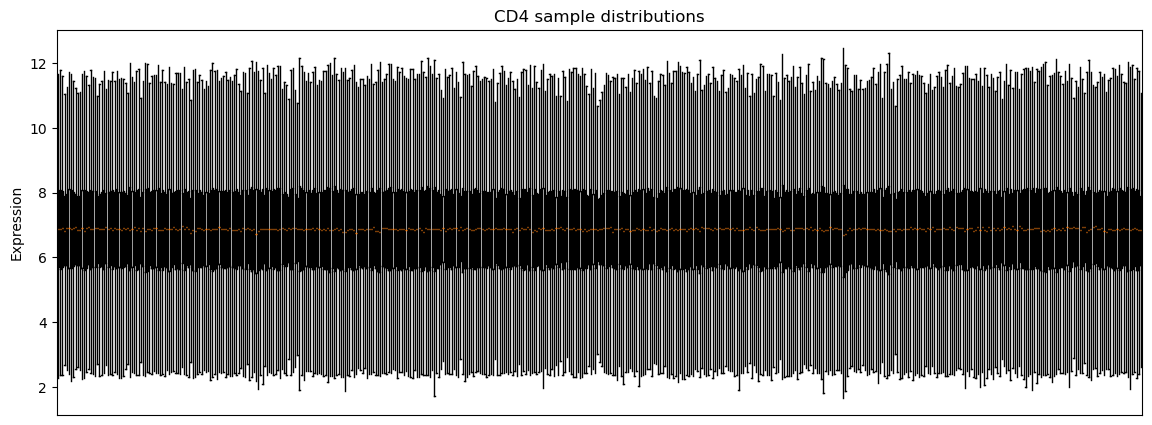

In [9]:
plt.figure(figsize=(14,5))
plt.boxplot(cd4_expr, showfliers=False)
plt.xticks([])
plt.ylabel("Expression")
plt.title("CD4 sample distributions")
plt.show()

In [10]:
cd14_expr.stack().describe()

count    1.040907e+07
mean     7.334730e+00
std      1.847979e+00
min     -1.454032e+00
25%      6.030259e+00
50%      7.228403e+00
75%      8.532532e+00
max      1.463801e+01
dtype: float64

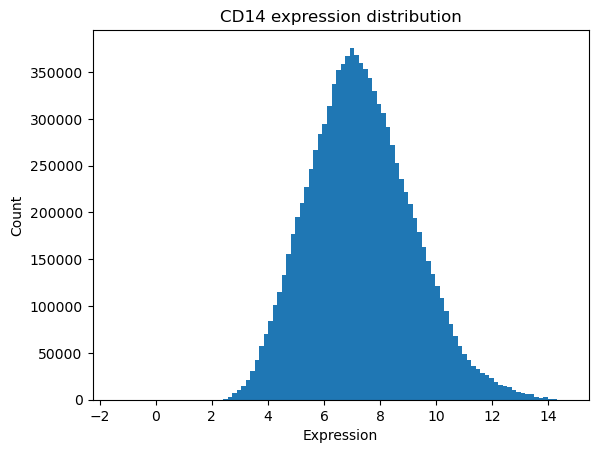

In [11]:
plt.hist(cd14_expr.stack(), bins=100)
plt.title("CD14 expression distribution")
plt.xlabel("Expression")
plt.ylabel("Count")
plt.show()

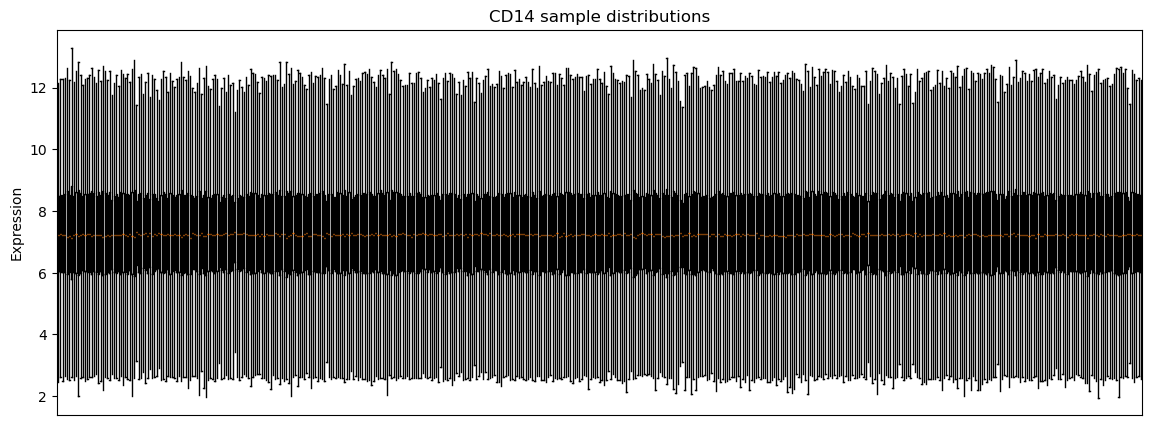

In [12]:
plt.figure(figsize=(14,5))
plt.boxplot(cd14_expr, showfliers=False)
plt.xticks([])
plt.ylabel("Expression")
plt.title("CD14 sample distributions")
plt.show()

## PCA

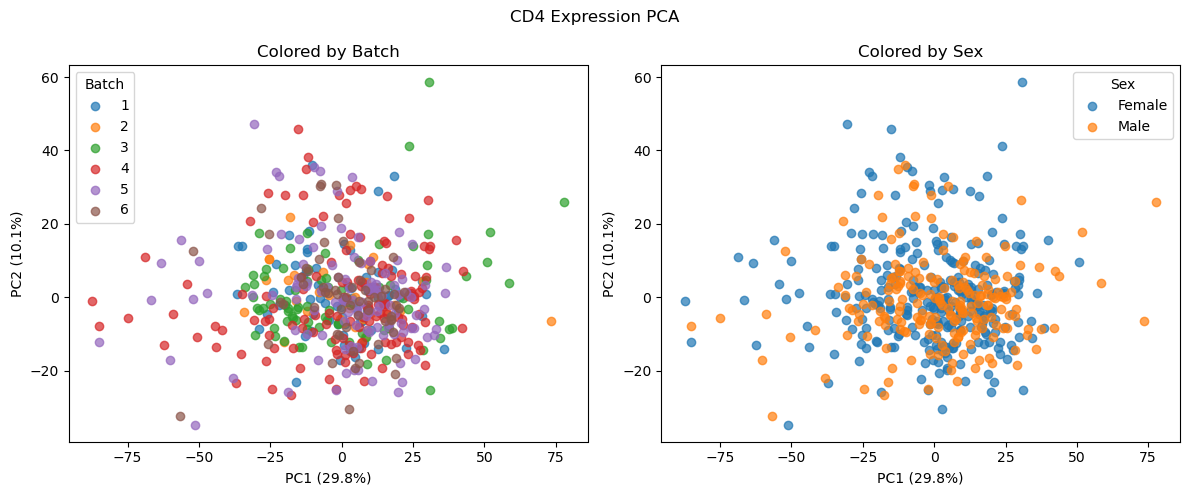

In [13]:
from sklearn.decomposition import PCA


# Match metadata order to expression matrix
cd4_meta = cd4_meta.set_index("geo_accession").loc[cd4_expr.columns]

# Run PCA
pca = PCA(n_components=2)
cd4_pca = pca.fit_transform(cd4_expr.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------
# Plot 1: Batch
# -----------------
for batch in sorted(cd4_meta["batch"].unique()):
    mask = cd4_meta["batch"] == batch
    axes[0].scatter(
        cd4_pca[mask, 0],
        cd4_pca[mask, 1],
        label=batch,
        alpha=0.7,
    )

axes[0].set_title("Colored by Batch")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend(title="Batch")

# -----------------
# Plot 2: Sex
# -----------------
for sex in sorted(cd4_meta["sex"].unique()):
    mask = cd4_meta["sex"] == sex
    axes[1].scatter(
        cd4_pca[mask, 0],
        cd4_pca[mask, 1],
        label=sex,
        alpha=0.7,
    )

axes[1].set_title("Colored by Sex")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend(title="Sex")

plt.suptitle("CD4 Expression PCA")
plt.tight_layout()
plt.show()


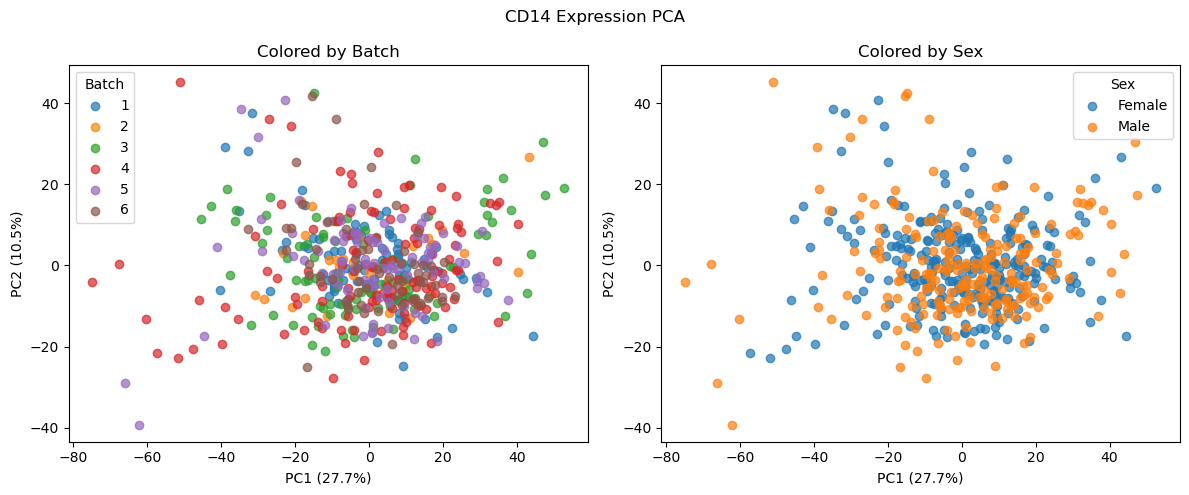

In [14]:
from sklearn.decomposition import PCA


# Match metadata order to expression matrix
cd14_meta = cd14_meta.set_index("geo_accession").loc[cd14_expr.columns]

# Run PCA
pca = PCA(n_components=2)
cd14_pca = pca.fit_transform(cd14_expr.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------
# Plot 1: Batch
# -----------------
for batch in sorted(cd14_meta["batch"].unique()):
    mask = cd14_meta["batch"] == batch
    axes[0].scatter(
        cd14_pca[mask, 0],
        cd14_pca[mask, 1],
        label=batch,
        alpha=0.7,
    )

axes[0].set_title("Colored by Batch")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend(title="Batch")

# -----------------
# Plot 2: Sex
# -----------------
for sex in sorted(cd14_meta["sex"].unique()):
    mask = cd14_meta["sex"] == sex
    axes[1].scatter(
        cd14_pca[mask, 0],
        cd14_pca[mask, 1],
        label=sex,
        alpha=0.7,
    )

axes[1].set_title("Colored by Sex")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend(title="Sex")

plt.suptitle("CD14 Expression PCA")
plt.tight_layout()
plt.show()


### Observations

- Sample distributions are consistent across arrays, suggesting preprocessing and normalization were successful.
- PCA does not reveal clustering by batch or sex, indicating these factors are not the dominant sources of expression variation.

## Conclusions

The expression matrices passed the basic quality-control checks:

- No missing values were detected.
- No duplicate probe identifiers were found.
- Expression samples matched the cleaned metadata.
- Expression distributions were similar across samples.

PCA of the log2-transformed expression matrices showed no obvious separation by batch or sex within either cell type. This does not exclude effects on individual genes or later principal components, but it indicates that neither variable dominates the leading global expression patterns.
